In [1]:
latent_dim=16

study_name = "arch_simple_cancer"
results_path = f"results/{study_name}"
# target_labels = ["encoded_element"]
problem_type = "classification"
data_type = "arcade"

In [2]:
""" Imports """
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from latent_model.supervised_prediction import create_loaders, create_models_list
from latent_model.models.supervised_model import SupervisedClassifier

warnings.simplefilter("ignore", category=ConvergenceWarning)

In [5]:
"""Utility Functions"""
if data_type == "arcade":
    inverse_mapping = {0: "colony", 1: "tissue"}
    cell_context_map = {"C": 0, "CH": 1}
    def transform_sample_id(sample_id):
        return torch.Tensor([cell_context_map[arr.split("_")[0]] for arr in sample_id])
else:
    def transform_sample_id(sample_id):
        return torch.Tensor([(int(arr.split("_")[0][-1]) - 1) % 2 for arr in sample_id])
    inverse_mapping = {0: "euploid", 1: "anueploid"}
    
def plot_regression_results(y_true, y_pred, label_type):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', label="Ideal Fit")
    plt.title(f"Parity Plot for {label_type}")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

def plot_classification_results(y_true, y_pred, label_type, class_names):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, colorbar=False)
    plt.title(label_type)
    plt.show()

def dataloader_to_numpy(dataloader):
    X_list, y_list = [], []
    for X_batch, y_batch in dataloader:
        y_labels = transform_sample_id(y_batch)
        X_list.append(X_batch.numpy())
        y_list.append(np.array(y_labels))

    X_full = np.vstack(X_list)
    y_full = np.concatenate(y_list)

    return X_full, y_full

In [4]:
all_loaders = {}
models = {}

for time_point_idx in range(9):
    all_loaders[time_point_idx] = create_loaders(results_path, time_point_idx=time_point_idx)
    models[time_point_idx] = {}
    for model_name in os.listdir(results_path):
        models[time_point_idx][model_name] = {}
        model_path = f"{results_path}/{model_name}/_best_model"
        for dataset_name in os.listdir(model_path):
            models[time_point_idx][model_name][dataset_name] = create_models_list()

In [6]:
best_models = {}
results = {}

for time_point_idx in range(9):
    loaders = all_loaders[time_point_idx]
    supervised_models = models[time_point_idx]
    
    best_models[time_point_idx] = {}
    results[time_point_idx] = {}
    
    for model_name, dataset in loaders.items():
        best_models[time_point_idx][model_name] = {}
        results[time_point_idx][model_name] = {}
        
        for dataset_name, loader in dataset.items():
            train_loader = loader.get_dataloader("train")
            val_loader = loader.get_dataloader("val")
            test_loader = loader.get_dataloader("test")
            
            best_accuracy = -np.inf
            best_model = None
            
            for model in supervised_models[model_name][dataset_name]:
                # Train
                X_train, y_train = dataloader_to_numpy(train_loader)
                optimal_params = model.grid_search(X_train, y_train)
                model_type = model.model_type
                optimized_model = SupervisedClassifier(model_type, optimal_params)
                optimized_model.fit(X_train, y_train)
                
                # Eval
                X_val, y_val = dataloader_to_numpy(val_loader)
                val_accuracy = optimized_model.evaluate(X_val, y_val, metric="accuracy")
                
                if val_accuracy > best_accuracy:
                    print(f"Timepoint {time_point_idx}: {model_name} | {dataset_name} | {model.model_type}: {val_accuracy}")
                    best_accuracy = val_accuracy
                    best_model = optimized_model
            
            best_models[time_point_idx][model_name][dataset_name] = best_model

            X_train, y_train = dataloader_to_numpy(train_loader)
            train_accuracy = best_model.evaluate(X_train, y_train, metric="accuracy")
            
            X_val, y_val = dataloader_to_numpy(val_loader)
            val_accuracy = best_model.evaluate(X_val, y_val, metric="accuracy")
            
            results[time_point_idx][model_name][dataset_name] = {
                "train_accuracy": train_accuracy,
                "val_accuracy": val_accuracy
            }
            
print(f"Training samples per timepoint: {len(train_loader.dataset)}")
print(f"Validation samples per timepoint: {len(val_loader.dataset)}")
print(f"Testing samples per timepoint: {len(test_loader.dataset)}")

Timepoint 0: ae | vascular_function_128 | logistic_regression: 0.875
Timepoint 0: cae | vascular_function_128 | logistic_regression: 0.8875
Timepoint 0: cae | vascular_function_128 | svm: 0.9
Timepoint 0: neuralop | vascular_function_128 | logistic_regression: 0.84375
Timepoint 0: neuralop | vascular_function_128 | random_forest: 0.8625
Timepoint 1: ae | vascular_function_128 | logistic_regression: 0.8625
Timepoint 1: ae | vascular_function_128 | svm: 0.875
Timepoint 1: cae | vascular_function_128 | logistic_regression: 0.79375
Timepoint 1: cae | vascular_function_128 | random_forest: 0.81875
Timepoint 1: neuralop | vascular_function_128 | logistic_regression: 0.7125
Timepoint 1: neuralop | vascular_function_128 | random_forest: 0.8
Timepoint 2: ae | vascular_function_128 | logistic_regression: 0.83125
Timepoint 2: ae | vascular_function_128 | svm: 0.8625
Timepoint 2: cae | vascular_function_128 | logistic_regression: 0.80625
Timepoint 2: cae | vascular_function_128 | random_forest: 0.

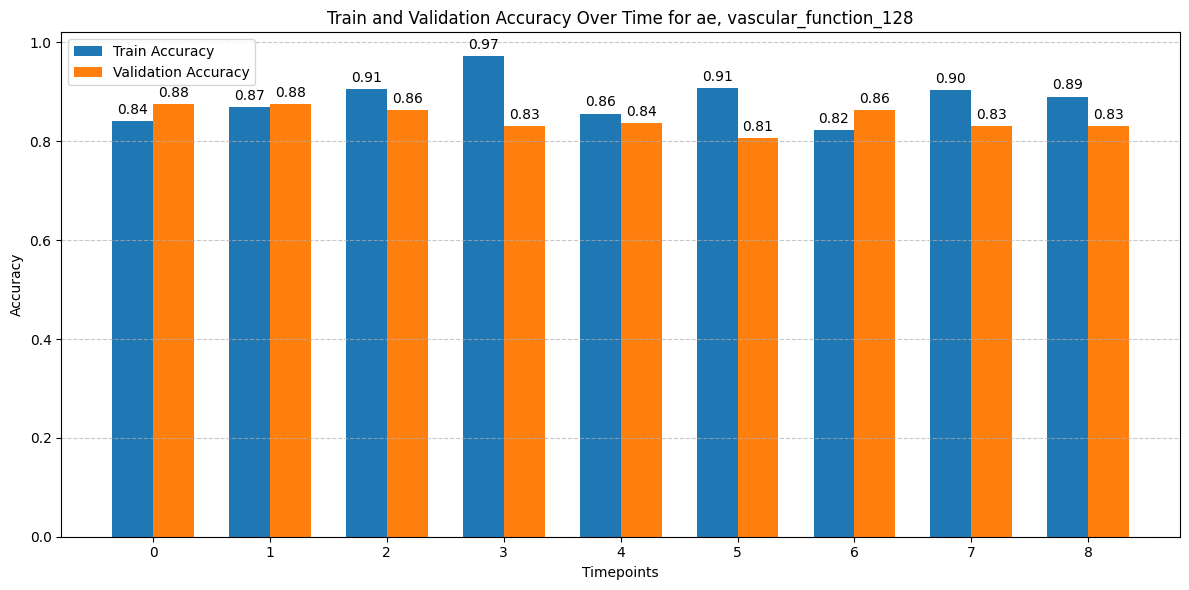

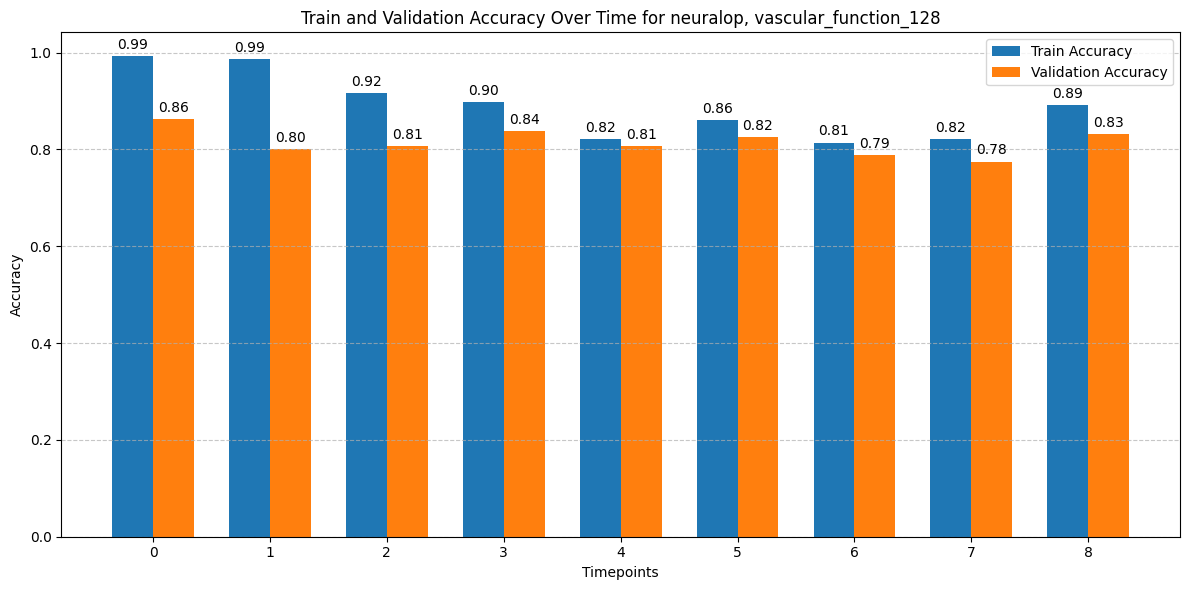

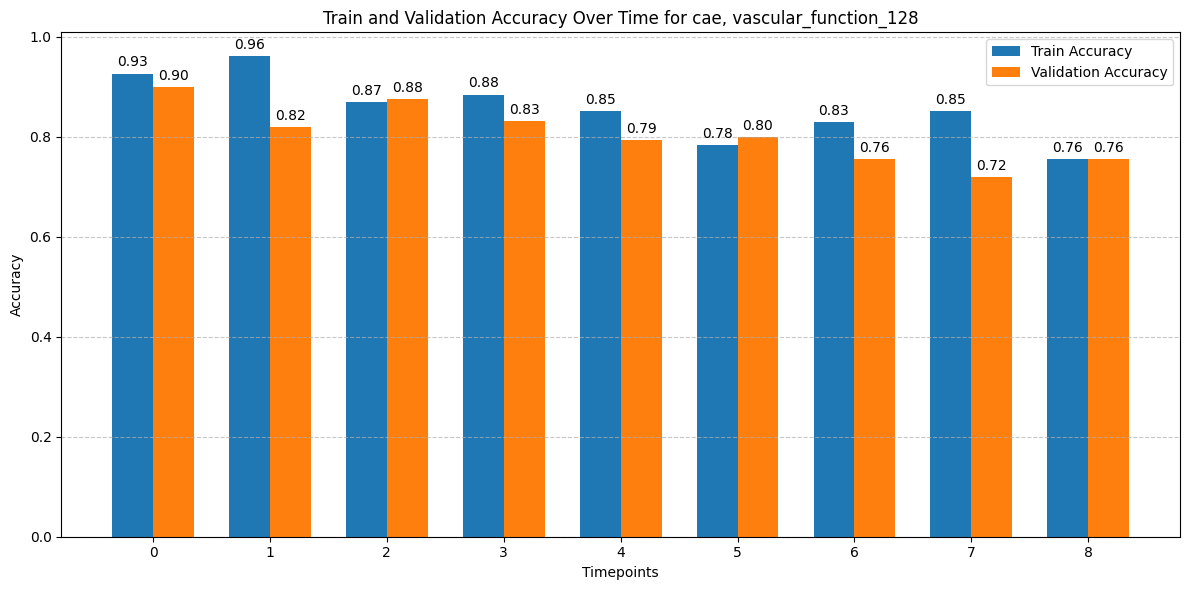

In [7]:
def plot_accuracy_over_time(results, model_name, dataset_name):
    """
    Plot train and validation accuracy over time for a specific model and dataset.
    
    Parameters:
    -----------
    all_timepoint_results : dict
        Dictionary containing accuracy results for each timepoint, model, and dataset
    model_name : str
        Name of the model to plot
    dataset_name : str
        Name of the dataset to plot
    """
    timepoints = sorted(results.keys())
    train_accuracies = []
    val_accuracies = []
    
    for tp in timepoints:
        if model_name in results[tp] and dataset_name in results[tp][model_name]:
            result = results[tp][model_name][dataset_name]
            train_accuracies.append(result["train_accuracy"])
            val_accuracies.append(result["val_accuracy"])
        else:
            train_accuracies.append(0)
            val_accuracies.append(0)
    
    x = np.arange(len(timepoints))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    train_bars = ax.bar(x - width/2, train_accuracies, width, label='Train Accuracy')
    val_bars = ax.bar(x + width/2, val_accuracies, width, label='Validation Accuracy')
    
    ax.set_xlabel('Timepoints')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Train and Validation Accuracy Over Time for {model_name}, {dataset_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints)
    ax.legend()
    
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', rotation=0)
    
    add_labels(train_bars)
    add_labels(val_bars)
    
    fig.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    return fig


def plot_all_combinations(all_timepoint_results):
    """
    Create plots for all model and dataset combinations.
    """
    model_names = set()
    dataset_names = set()

    for tp in all_timepoint_results:
        for model_name in all_timepoint_results[tp]:
            model_names.add(model_name)
            for dataset_name in all_timepoint_results[tp][model_name]:
                dataset_names.add(dataset_name)

    # Plot for each combination
    for model_name in model_names:
        for dataset_name in dataset_names:
            fig = plot_accuracy_over_time(all_timepoint_results, model_name, dataset_name)
            plt.show()

plot_all_combinations(results)

In [10]:
for model_name, dataset in best_models.items():
    for dataset_name, model in dataset.items():
        X_test, y_test = dataloader_to_numpy(test_loader)

        # Test
        y_pred = model.predict(X_test)
                
        # Map to discrete
        y_pred_labels = [int(label > 0.5) for label in y_pred]
        class_names = inverse_mapping.values()
        y_test_original = [inverse_mapping[label] for label in y_test]
        y_pred_original = [inverse_mapping[label] for label in y_pred]

        print(classification_report(y_test_original, y_pred_original, zero_division=0))
        plot_classification_results(y_test, y_pred_labels, f"{model_name} | {dataset_name}", class_names)

AttributeError: 'dict' object has no attribute 'predict'